In [19]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import quantile_transform
from IPython.display import HTML, display

# Macroeconomic data from FRED-MD

In [20]:
fred_md = pd.read_csv("./datasets/FRED_MD_2026_05.csv")

# Keep transformation row before converting dates
transforms = fred_md.loc[fred_md["sasdate"] == "Transform:"].iloc[0].drop("sasdate")
transforms = transforms.astype(int).to_dict()

fred_md = fred_md[fred_md["sasdate"] != "Transform:"].copy()
fred_md["sasdate"] = pd.to_datetime(fred_md["sasdate"], format="%m/%d/%Y")
fred_md = fred_md.set_index("sasdate")
fred_md = fred_md.apply(pd.to_numeric, errors="coerce")
fred_md = fred_md.sort_index()
fred_md = fred_md.loc["1963-6-01":"2026-04-01"]

fred_md.head()

,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
sasdate,,,,,,,,,,,,,,,,,,,,,
1963-06-01,3058.664,2861.0,17.881,304332.5361,20542.37530,27.0622,28.9373,27.7977,39.3274,26.1278,...,18.915,11.126,2.46,2.98,2.34,NaN,7984.0,18236.0,90.0224,12.0403
1963-07-01,3060.387,2862.7,17.973,312852.1672,20780.80730,26.9545,28.9373,27.7977,39.2095,26.1019,...,18.993,11.139,2.47,2.99,2.35,NaN,8110.0,18497.0,90.2269,14.2966
1963-08-01,3071.095,2872.9,18.037,310735.2354,20754.65020,27.0083,29.1983,28.1047,39.5238,26.1537,...,19.040,11.150,2.47,3.01,2.34,96.4,8185.0,18750.0,88.9845,11.4839
1963-09-01,3091.894,2893.0,18.003,307838.1396,20703.34205,27.2776,29.2853,28.1884,39.6417,26.6203,...,18.954,11.164,2.48,3.01,2.36,NaN,8123.0,18867.0,89.5672,13.0301
1963-10-01,3109.050,2908.9,17.993,316321.4105,21063.50515,27.4661,29.5462,28.3838,39.9167,26.6462,...,18.989,11.193,2.48,3.02,2.36,NaN,8179.0,19064.0,90.1585,13.8203


Selecting a subset of the FRED-MD database to avoid lots of overlapping fields

In [21]:
selected_cols = [
    # (i) Output and activity
    "RPI",
    "W875RX1",
    "DPCERA3M086SBEA",
    "RETAILx",
    "INDPRO",
    "IPMANSICS",
    "CUMFNS",

    # (ii) Employment
    "UNRATE",
    "UEMPMEAN",
    "CLAIMSx",
    "PAYEMS",
    "MANEMP",
    "SRVPRD",
    "AWHMAN",

    # (iii) Inflation
    "CPIAUCSL",
    "CPIULFSL",
    "PCEPI",
    "WPSFD49207",
    "WPSID61",
    "OILPRICEx",

    # (iv) Interest rates and term spreads
    "HOUST",
    "FEDFUNDS",
    "GS1",
    "GS10",
    "T10YFFM",

    # (v) Credit spreads
    "AAA",
    "BAA",
    "AAAFFM",
    "BAAFFM",

    # (vi) Money and liquidity
    "M2SL",
    "BOGMBASE",
    "BUSLOANS",

    # (vii) Financial market stress proxies
    "S&P 500",
    "S&P PE ratio",
    "VIXCLSx",
]

Check for missing values in the selected columns

In [22]:
# Find columns with missing values
nans = []
for col in selected_cols:
    if not (col in fred_md.dropna(axis=1).columns):
        nans.append(col)

print(f"There are {len(nans)} columns with missing values: {', '.join(nans)}")
print("How many missing values are there from each field?")
fred_md[nans].isna().sum()

There are 4 columns with missing values: UNRATE, UEMPMEAN, CPIAUCSL, CPIULFSL
How many missing values are there from each field?


UNRATE      1
UEMPMEAN    1
CPIAUCSL    1
CPIULFSL    1
dtype: int64

These missing values all apear for the month of October 2025, like I saw in the previous notebook. There is only 1 missing date, which I assume we can fill with linear interpolation. Or with some sort of clever graph method? 

In [23]:
fred_md_selected = fred_md[selected_cols]
summary_data = []

def get_max_flatline(series):
    if len(series) < 2:
        return 0
    return (series.diff() == 0).astype(int).groupby((series.diff() != 0).cumsum()).sum().max()

for col in fred_md_selected.columns:
    summary_data.append({
        "Column Name": col,
        "Start": fred_md_selected[col].first_valid_index(),
        "End": fred_md_selected[col].last_valid_index(),
        "N Null": fred_md_selected[col].isna().sum(),
        "N Not-Null": fred_md_selected[col].notnull().sum(),
        "N Unique": fred_md_selected[col].nunique(),
        "Max Flatline": get_max_flatline(fred_md_selected[col])
    })

summary_df = pd.DataFrame(summary_data)
summary_df


,Column Name,Start,End,N Null,N Not-Null,N Unique,Max Flatline
0,RPI,1963-06-01,2026-04-01,0,755,755,0
1,W875RX1,1963-06-01,2026-04-01,0,755,755,0
2,DPCERA3M086SBEA,1963-06-01,2026-04-01,0,755,752,0
3,RETAILx,1963-06-01,2026-04-01,0,755,753,1
4,INDPRO,1963-06-01,2026-04-01,0,755,753,1
5,IPMANSICS,1963-06-01,2026-04-01,0,755,753,1
6,CUMFNS,1963-06-01,2026-04-01,0,755,754,0
7,UNRATE,1963-06-01,2026-04-01,1,754,74,8
8,UEMPMEAN,1963-06-01,2026-04-01,1,754,239,3
9,CLAIMSx,1963-06-01,2026-04-01,0,755,651,1


- **N Null**: 448 missing datapoints for quarterly data is expected. There is however one missing datapoint for `UNRATE`, `UEMPMEAN`, `CPIAUCSL`, and `CPIULFSL`. I imagine that we can linearly interpolate for this small discrepency, or find new data. I think that it is justifiable to interpolate here.
- **N Not-Null vs. N Unique**: The repeats seem to be due to rounding. The `UNRATE` looked suspicious, but the values are provided to one decimal-place and the mean is 6.1 with a standard deviation of 1.7. Similary, `AWHMAN` is the average weekly hours of production which is set by factories and unions etc. There is a mean of 40.8 and a standard deviation of 0.7, so with only one decimal place, I think that not many unique values is reasonable.
- **Max Flatline** (longest stretch of the same value): I am suspicious of `UNRATE`, `AWHMAN`, `OILPRICEx`, and `FEDFUNDS`.
    - `UNRATE`: At the height of the dot-com bubble, US unemployment remained steadily low ([1]. I suspect they are using the same data as FRED anyway, but google seems to agree that this was a steady time)
    - `AWHMAN`: I see no reason that the average weekly hours of production can't remain stationary for 9 months. I have checked another dataset [5] which reports the same dataset but for private companies and they report a $\pm 0.1$ deviation throughout this period.
    - `OILPRICEx`:  In the 70s oil prices were set by the oil companies called "posted prices", rather than being set by the free-market [3], so the prices were extremely stable. The spot price of oil only didn't exist on the free market until 1983. The posted prices were not what was actually charged, so this seems like a bit of a poor indicator. There is a monthly consumer price index for fuel oil and other fuels in the US which goes back to 1970 [4], but I am not sure if this is a replacement for pure oil price.
    - `FEDFUNDS`: Fed funds rate remained unchanged from August 2023-2024 so this looks fine [2]


1. https://www.macrotrends.net/1316/us-national-unemployment-rate
2. https://www.gam.com/en/our-thinking/multi-asset-blog/fed-leaves-interest-rates-unchanged-as-expected-august-2024
3. https://blogs.worldbank.org/en/developmenttalk/how-do-current-oil-market-conditions-differ-those-during-price-shocks-1970s
4. https://fred.stlouisfed.org/series/CUSR0000SEHE
5. https://fred.stlouisfed.org/data/AWHNONAG

### Plotting each of the time series

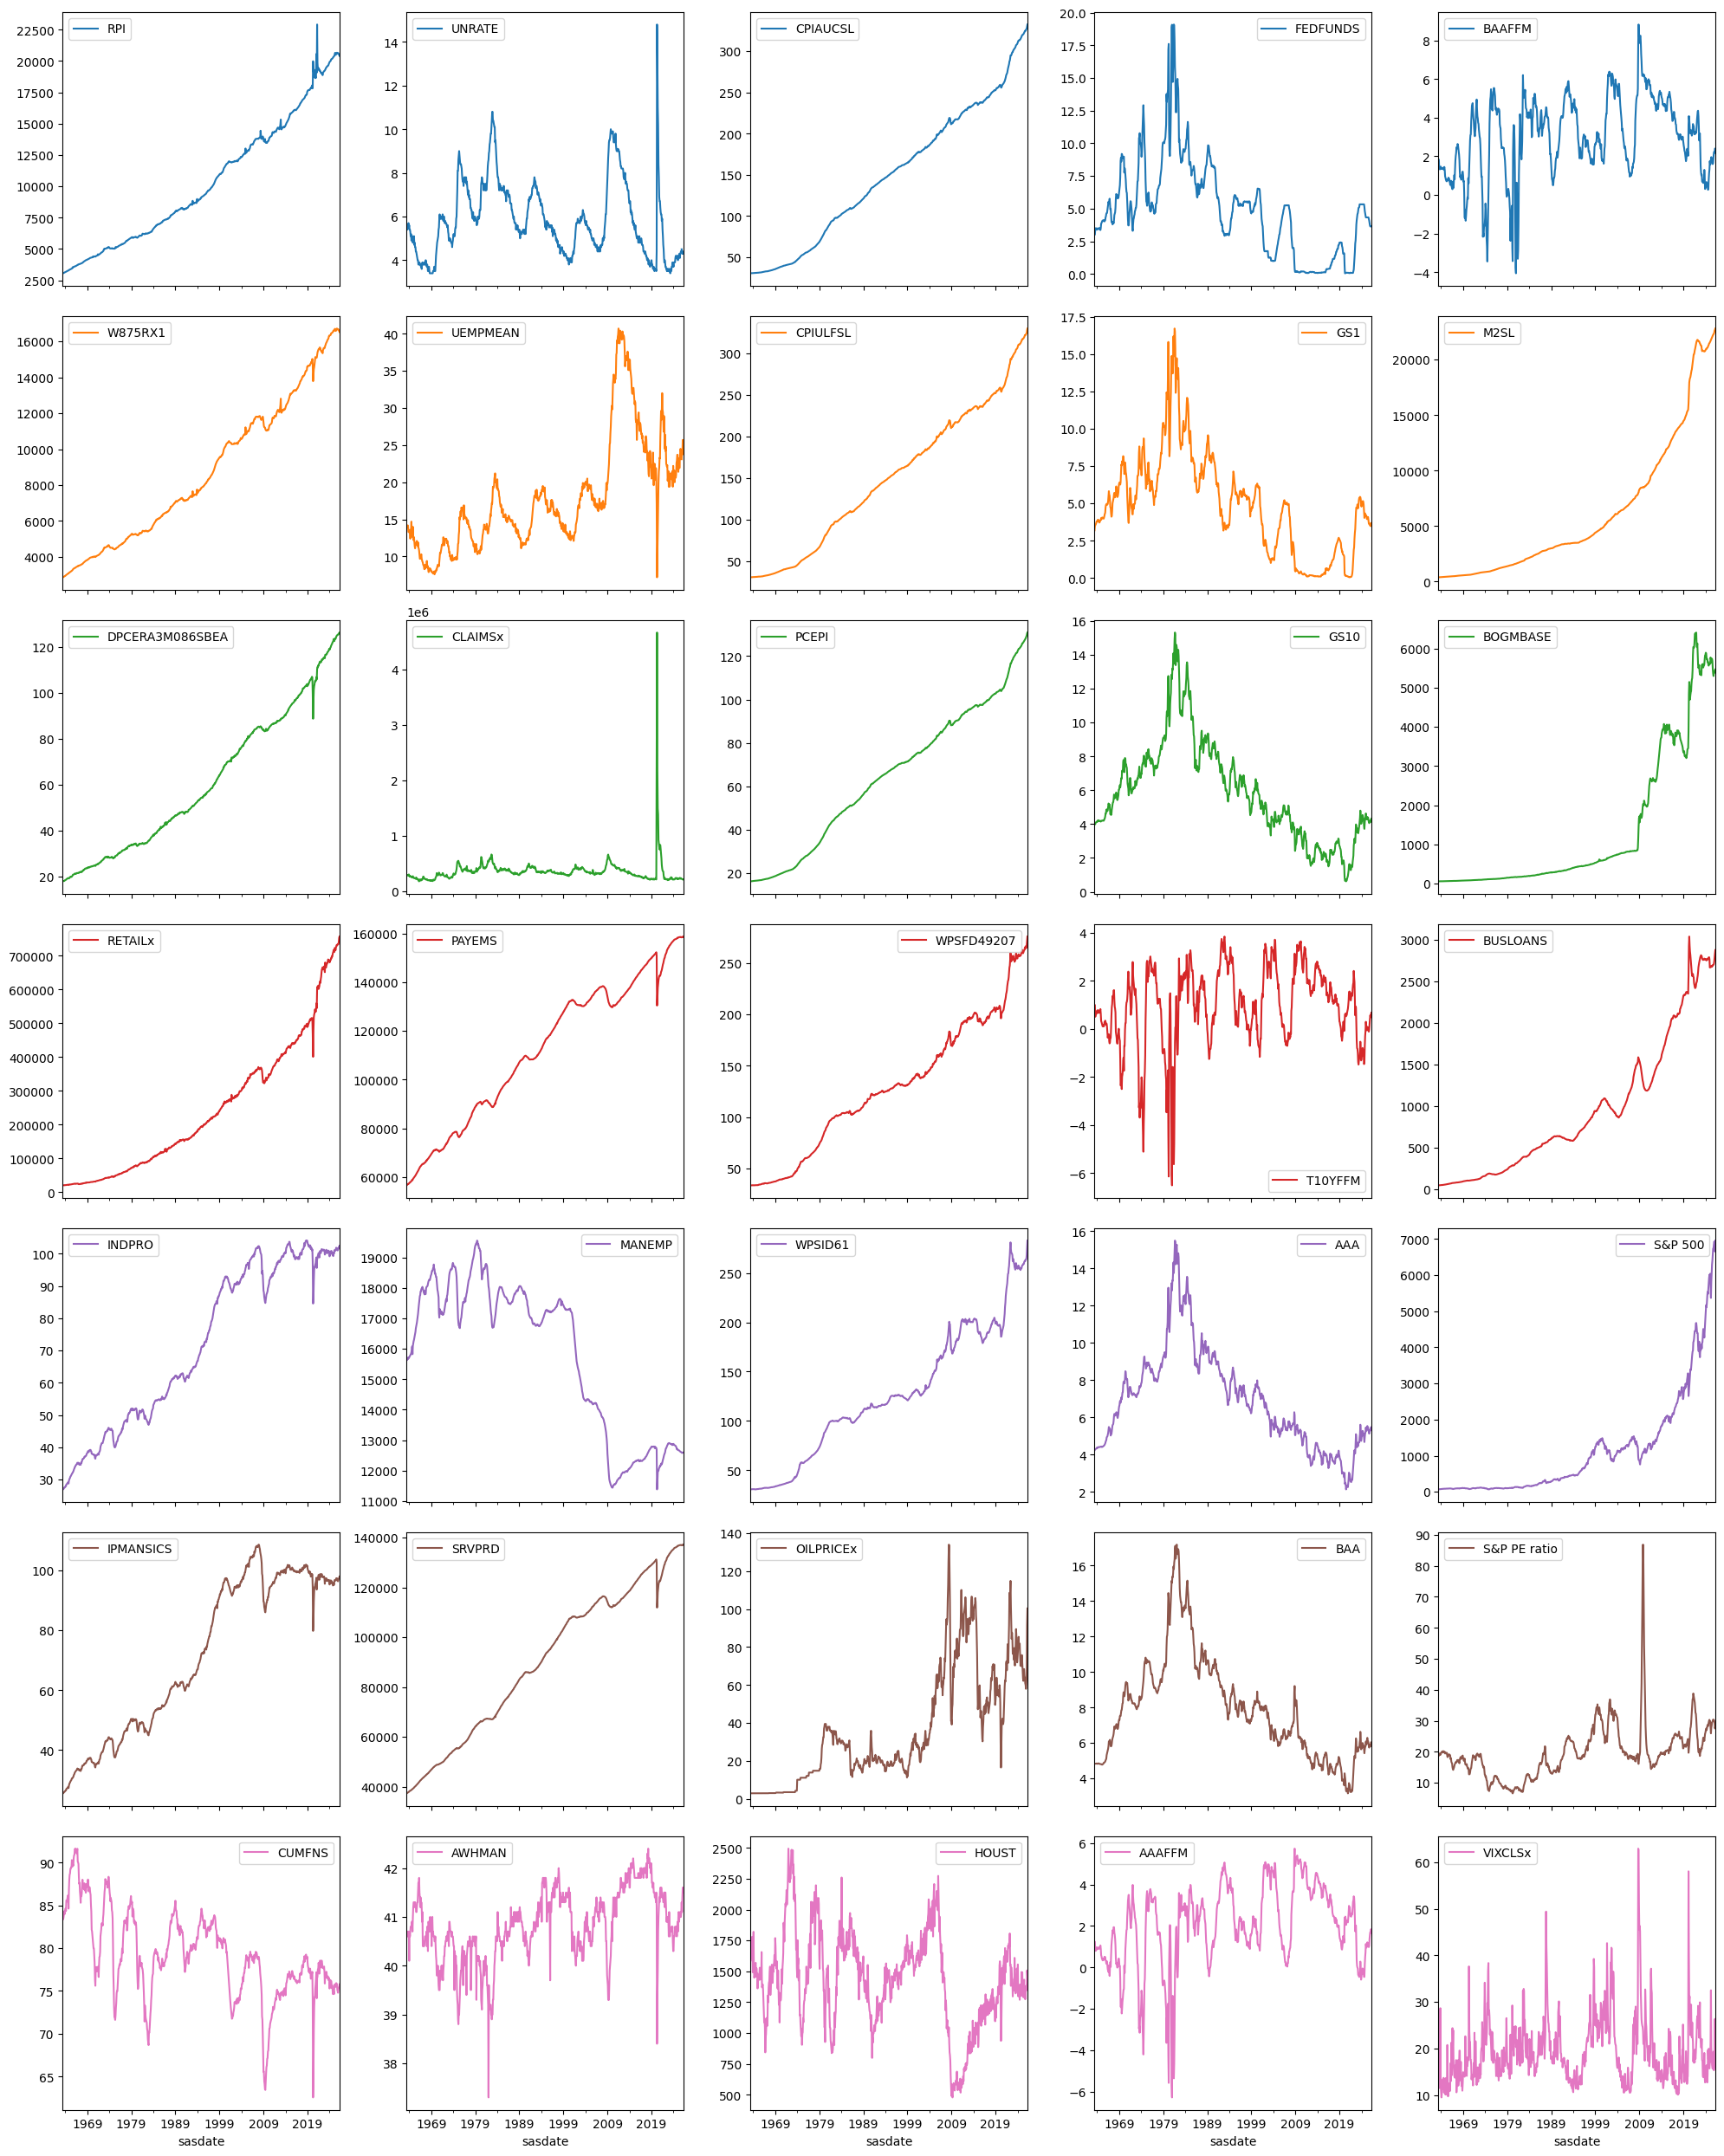

In [154]:
num_rows = 7 
fig, axes = plt.subplots(num_rows, 5, figsize=(20, 25), sharex=True)

col1_axes = axes[:, 0]
col2_axes = axes[:, 1]
col3_axes = axes[:, 2]
col4_axes = axes[:, 3]
col5_axes = axes[:, 4]

fred_md_selected[selected_cols[:7]].plot(subplots=True, ax=col1_axes[:7])
fred_md_selected[selected_cols[7:14]].plot(subplots=True, ax=col2_axes[:len(selected_cols[7:14])])
fred_md_selected[selected_cols[14:21]].plot(subplots=True, ax=col3_axes[:len(selected_cols[14:21])])
fred_md_selected[selected_cols[21:28]].plot(subplots=True, ax=col4_axes[:len(selected_cols[21:28])])
fred_md_selected[selected_cols[28:]].plot(subplots=True, ax=col5_axes[:len(selected_cols[28:])])

plt.tight_layout()
plt.show()


This seems to be quite a good spread of variables. Lots are quite similar so maybe we can remove later on if it is suitable.

Importantly, there seems to be no missing data, it all looks good.

### Transforming the variables

The column tcode denotes the following data transformation for a series $x$: (1) no transformation; (2) $\Delta x_t$; (3) $\Delta^2 x_t$; (4) $\log(x_t)$; (5) $\Delta \log(x_t)$; (6) $\Delta^2 \log(x_t)$; (7) $\Delta (x_t/x_{t−1} − 1.0)$.

Before doing this, I needed to address the missing values in October 2025, this is because any transform involving a difference returns NaN around the missing values.

In [24]:
fred_md_selected[nans].loc["8/1/2025":"12/1/2025"]

,UNRATE,UEMPMEAN,CPIAUCSL,CPIULFSL
sasdate,,,,
2025-08-01,4.3,24.5,323.291,320.497
2025-09-01,4.4,24.1,324.245,321.478
2025-10-01,NaN,NaN,NaN,NaN
2025-11-01,4.5,23.1,325.063,322.372
2025-12-01,4.4,24.4,326.031,323.150


In [25]:
fred_md_selected = fred_md_selected.interpolate(method="linear")
fred_md_selected[nans].loc["8/1/2025":"12/1/2025"]

,UNRATE,UEMPMEAN,CPIAUCSL,CPIULFSL
sasdate,,,,
2025-08-01,4.30,24.5,323.291,320.497
2025-09-01,4.40,24.1,324.245,321.478
2025-10-01,4.45,23.6,324.654,321.925
2025-11-01,4.50,23.1,325.063,322.372
2025-12-01,4.40,24.4,326.031,323.150


In [26]:
def transform_series(x, tcode, lag=1):
    x = x.astype(float)
    if   tcode == 1: return x
    elif tcode == 2: return x.diff(lag)
    elif tcode == 3: return x.diff(lag).diff(1)
    elif tcode == 4: return np.log(x)
    elif tcode == 5: return np.log(x).diff(lag)
    elif tcode == 6: return np.log(x).diff(lag).diff(1)
    elif tcode == 7: return x.pct_change(lag).diff(1)
    else: raise ValueError(f"Unknown transformation code: {tcode}")

activity_vars = ["SRVPRD", "PAYEMS", "MANEMP", "IPMANSICS", "INDPRO", "DPCERA3M086SBEA", "CUMFNS", "W875RX1"]

transforms_levels = transforms.copy()
transforms_levels["UNRATE"] = 1
transforms_levels["CLAIMSx"] = 4

fred_md_transformed = pd.DataFrame(index=fred_md_selected.index)

for col in fred_md_selected.columns:
    if col in activity_vars:
        lag=12
    else:
        lag=1
    
    fred_md_transformed[col] = transform_series(fred_md_selected[col], transforms_levels[col], lag=lag)

fred_md_transformed = fred_md_transformed.replace([np.inf, -np.inf], np.nan)
fred_md_transformed = fred_md_transformed.dropna()
fred_md_transformed.shape

(743, 35)

The changes I have made here is to tak the year-on-year differences for all the variables in `activity_vars` instead of the *suggested* month-on-month differences, this is because these variables are 12 month periodic anyway and so taking year on year differences makes economic sense and results in a cleaner time series.

I have changed the transform of `UNRATE` to just return levels instead of the first difference, now describing "unemployment rate" as opposed to "change in unumployment rate". I have changed the transform of `CLAIMSx` from the first difference of the logarithm of the series to simply the logarithm, now we describe the "logarithm of the number of unemployment claims" instead of the "monthly percentage change in unemployment claims". Both these new series are stationary by the ADS test and KPSS test.

So here we have our $x(t)$ series observations: $X\in\mathbb{R}^{743\times35}$

# Industry returns data from Kenneth R. French Library
Getting price data of 10 industry portfolios, this is our $y(t)$ series.

Data is from the Kenneth R. French library: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html

In [27]:
prices = pd.read_csv("./datasets/10_Industry_Portfolios.csv")
prices.set_index("Date", inplace=True)
prices.index = pd.to_datetime(prices.index.astype(str), format="%Y%m")
prices = prices.loc["1963-08-01":"2026-04-01"]
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 753 entries, 1963-08-01 to 2026-04-01
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NoDur   753 non-null    float64
 1   Durbl   753 non-null    float64
 2   Manuf   753 non-null    float64
 3   Enrgy   753 non-null    float64
 4   HiTec   753 non-null    float64
 5   Telcm   753 non-null    float64
 6   Shops   753 non-null    float64
 7   Hlth    753 non-null    float64
 8   Utils   753 non-null    float64
 9   Other   753 non-null    float64
dtypes: float64(10)
memory usage: 64.7 KB


In [28]:
# 1. Initialize a list to hold the row data
summary_data = []

# 2. Helper function to calculate the longest flatline period
def get_max_flatline(series):
    # If the series has fewer than 2 elements, flatline is 0
    if len(series) < 2:
        return 0
    return (series.diff() == 0).astype(int).groupby((series.diff() != 0).cumsum()).sum().max()

# 3. Gather metrics for each column in df
for col in prices.columns:
    summary_data.append({
        "Column Name": col,
        "Start": prices[col].first_valid_index(),
        "End": prices[col].last_valid_index(),
        "N Null": prices[col].isna().sum(),
        "N Not-Null": prices[col].notnull().sum(),
        "N Unique": prices[col].nunique(),
        "Max Flatline": get_max_flatline(prices[col])
    })


# 5. Convert to a DataFrame and display without the row index numbers
summary_df = pd.DataFrame(summary_data)
summary_df


,Column Name,Start,End,N Null,N Not-Null,N Unique,Max Flatline
0,NoDur,1963-08-01,2026-04-01,0,753,588,1
1,Durbl,1963-08-01,2026-04-01,0,753,654,0
2,Manuf,1963-08-01,2026-04-01,0,753,601,0
3,Enrgy,1963-08-01,2026-04-01,0,753,625,1
4,HiTec,1963-08-01,2026-04-01,0,753,627,0
5,Telcm,1963-08-01,2026-04-01,0,753,608,1
6,Shops,1963-08-01,2026-04-01,0,753,614,1
7,Hlth,1963-08-01,2026-04-01,0,753,614,1
8,Utils,1963-08-01,2026-04-01,0,753,569,1
9,Other,1963-08-01,2026-04-01,0,753,609,1


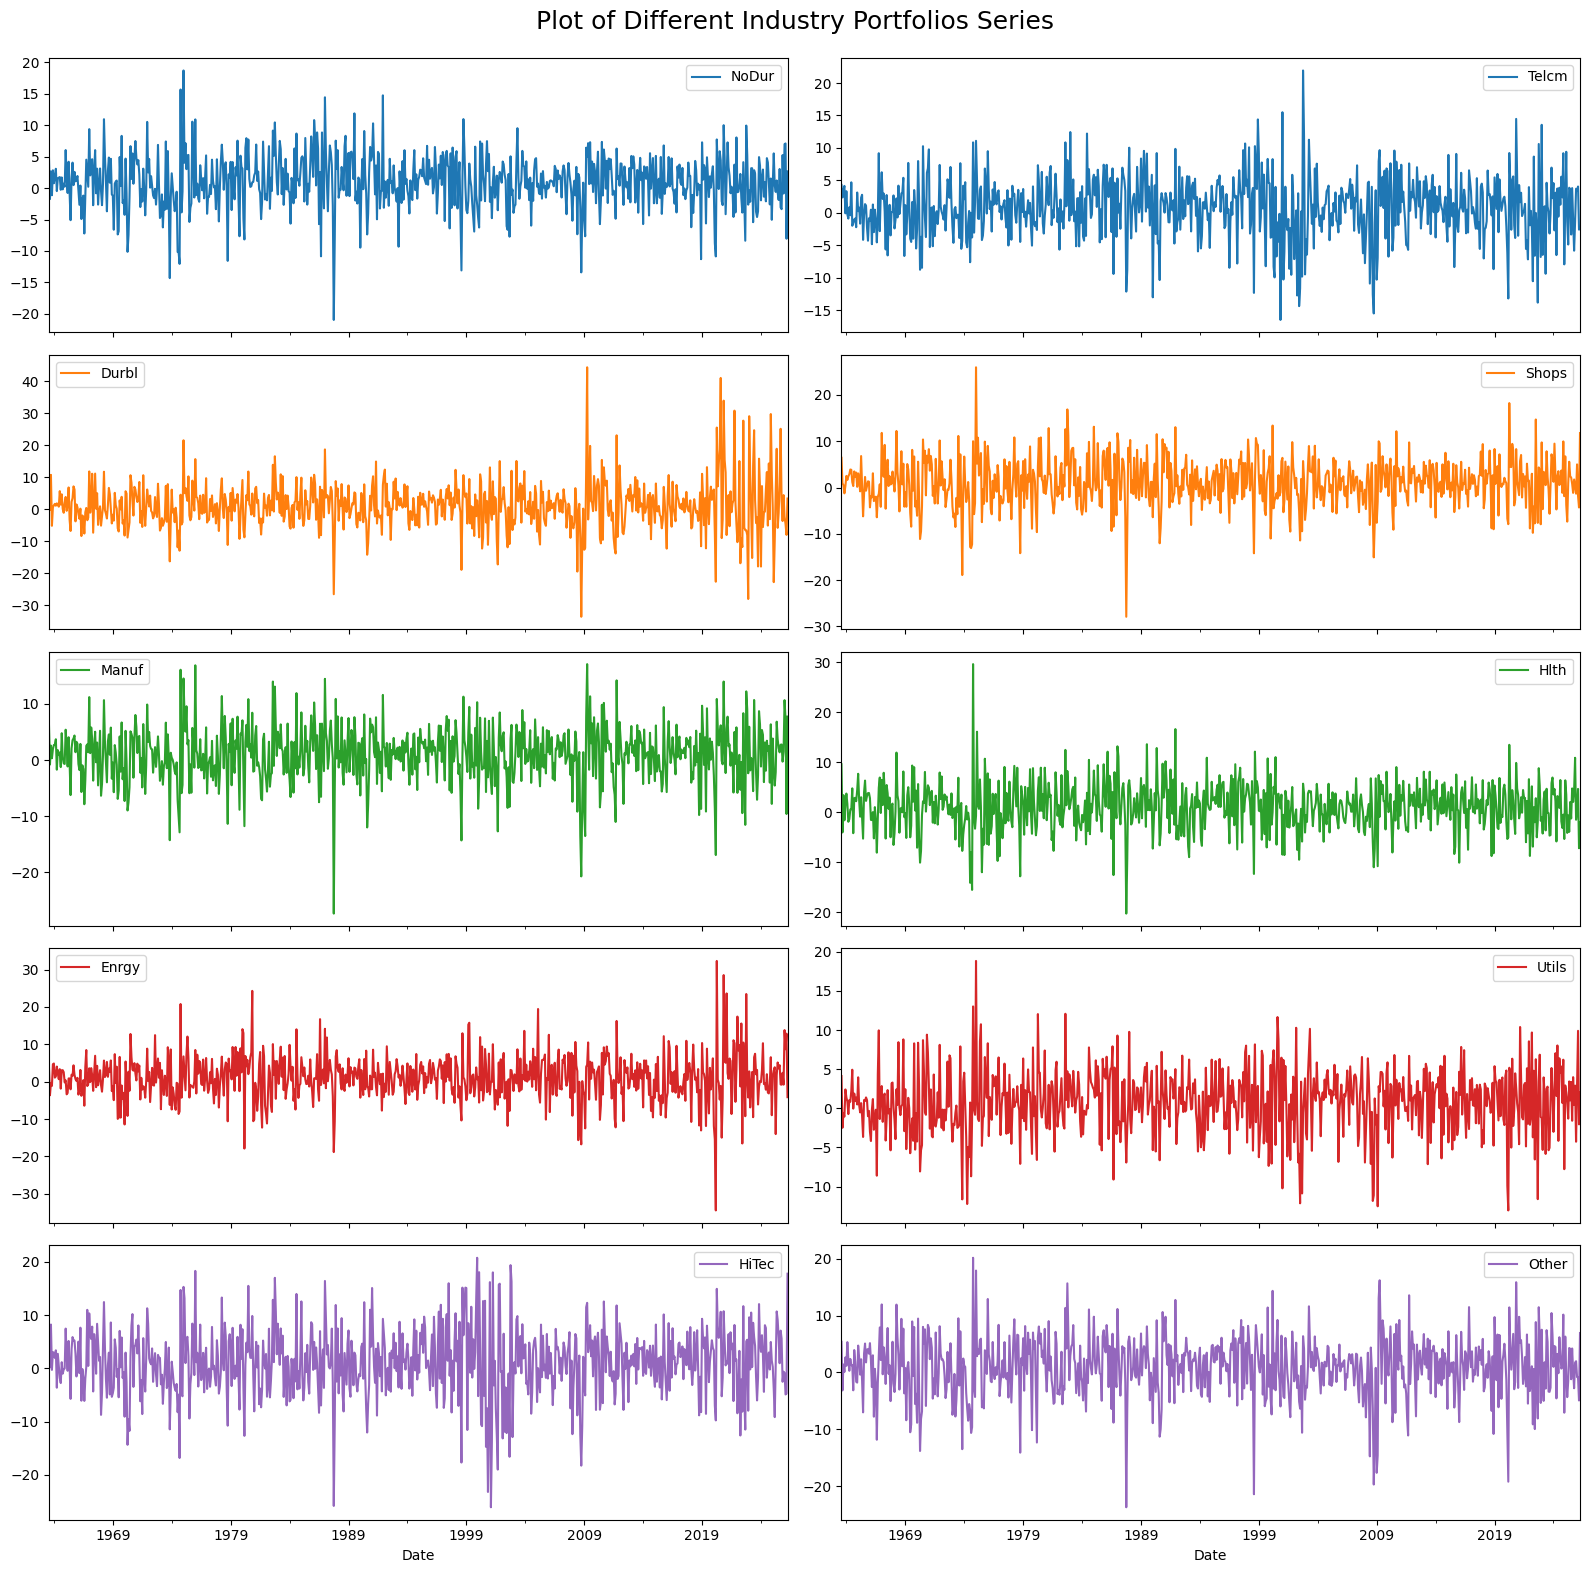

In [29]:
# 17 rows of plots, 2 columns side-by-side
num_rows = 5
fig, axes = plt.subplots(num_rows, 2, figsize=(16, 16), sharex=True)

fig.suptitle("Plot of Different Industry Portfolios Series", fontsize=18)

# Flatten the axes array into 1D arrays for each column
col1_axes = axes[:, 0]
col2_axes = axes[:, 1]

# Plot first 17 columns in the left column
prices[prices.columns[:5]].plot(subplots=True, ax=col1_axes[:5])
prices[prices.columns[5:]].plot(subplots=True, ax=col2_axes[:len(prices.columns[5:])])


# Turn off any unused empty subplots in the grid
for ax in axes.flat:
    if not ax.has_data():
        ax.set_visible(False)


fig.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

The returns series does not need any transformations because they are already stationary series. This is our $y(t)$ series: $Y\in\mathbb{R}^{753\times10}$


### Standardising our data

Here we use the quantile method for standardisation. This is after lots of testing with different methdods, which you can see the main results for below and the rest of the results on GitHub in 'brief_phase1.ipynb' (30/06/2026)

In [30]:
pre_standardsised_joint = fred_md_transformed.join(prices, on="sasdate")

joint_df_standardised = pd.DataFrame(quantile_transform(pre_standardsised_joint, n_quantiles=pre_standardsised_joint.shape[0]), index=pre_standardsised_joint.index, columns=pre_standardsised_joint.columns)
dates = joint_df_standardised.index; variables = joint_df_standardised.columns

Adding in an indicator variable for when the economy is in a recession. The dates of recessions are provided by FRED: https://fredhelp.stlouisfed.org/fred/data/understanding-the-data/recession-bars/

In [31]:
recession_dates = [("1969-12-01", "1970-11-01"), ("1973-11-01", "1975-03-01"), ("1980-01-01", "1980-07-01"), ("1981-07-01", "1982-11-01"), ("1990-07-01", "1991-03-01"), ("2001-03-01", "2001-11-01"), ("2007-12-01", "2009-06-01"), ("2020-02-01", "2020-04-01")]

final_df = joint_df_standardised.copy(); final_df["recession"] = 0

for start, end in recession_dates:
    final_df.loc[start:end, "recession"] = 1

final_df.to_parquet("./datasets/joint_df_quantile.parquet")

# Phase 1 outputs

### Final Clean Matrix
We want $z(t) = (x(t), y(t))$, so we have $\tilde Z = [\tilde X \ \tilde Y] \in \mathbb{R}^{743 \times 45}$

### Data Audit Table

| Item                                 | Value                                                                                                                                                                                                                          |
| ------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Dataset Name**                     | FRED-MD (Federal Reserve Economic Data - Monthly Database)                                                                                                                                                                     |
| **Sample Period**                    | 1963-08-01 to 2026-04-01                                                                                                                                                                                                       |
| **Number of Observations (N)**       | 753 monthly observations                                                                                                                                                                                                       |
| **Raw Dimension $(D_\text{raw})$** | 136 variables                                                                                                                                                                                                                  |
| **Final Dimension $(D)$**            | 45 variables                                                                                                                                                                                                                   |
| **Transformation Rules**             | FRED-MD transformation codes: (1) $(x_t)$; (2) $(\Delta x_t)$; (3) $(\Delta^2 x_t)$; (4) $(\log(x_t))$; (5) $(\Delta \log(x_t))$; (6) $(\Delta^2 \log(x_t))$; (7) $(\Delta(x_t/x_{t-1}-1))$. As noted above, some activity variables have been transformed using YoY instead of MoM transformations, despite FRED-MD codes. This is less noisy and still economically interpretable. `UNRATE` and `CLAIMSx` have both been investigated further due to high kertosis. Their transformations have been changed completly to improve structure. Their interpretations are still economically meaningful, but no longer as initially intended.                                                 |
| **Missing Data Treatment**           | Four isolated missing observations were identified across four variables. These represented less than 0.02% of the dataset and were imputed using linear interpolation. No other missing values were present after processing. |
| **Variables Retained**               | 35 variables selected to represent output and activity, labour markets, housing, inflation, interest rates, credit conditions, money and liquidity, and financial market stress. 10 industry portfolios included for potential pricing estimation.                                |
| **Variables Removed**                | 91 variables removed due to redundancy, high collinearity, excessive sectoral disaggregation, or overlap with retained indicators. Full list reported in Appendix X.                                                           |

### Plots

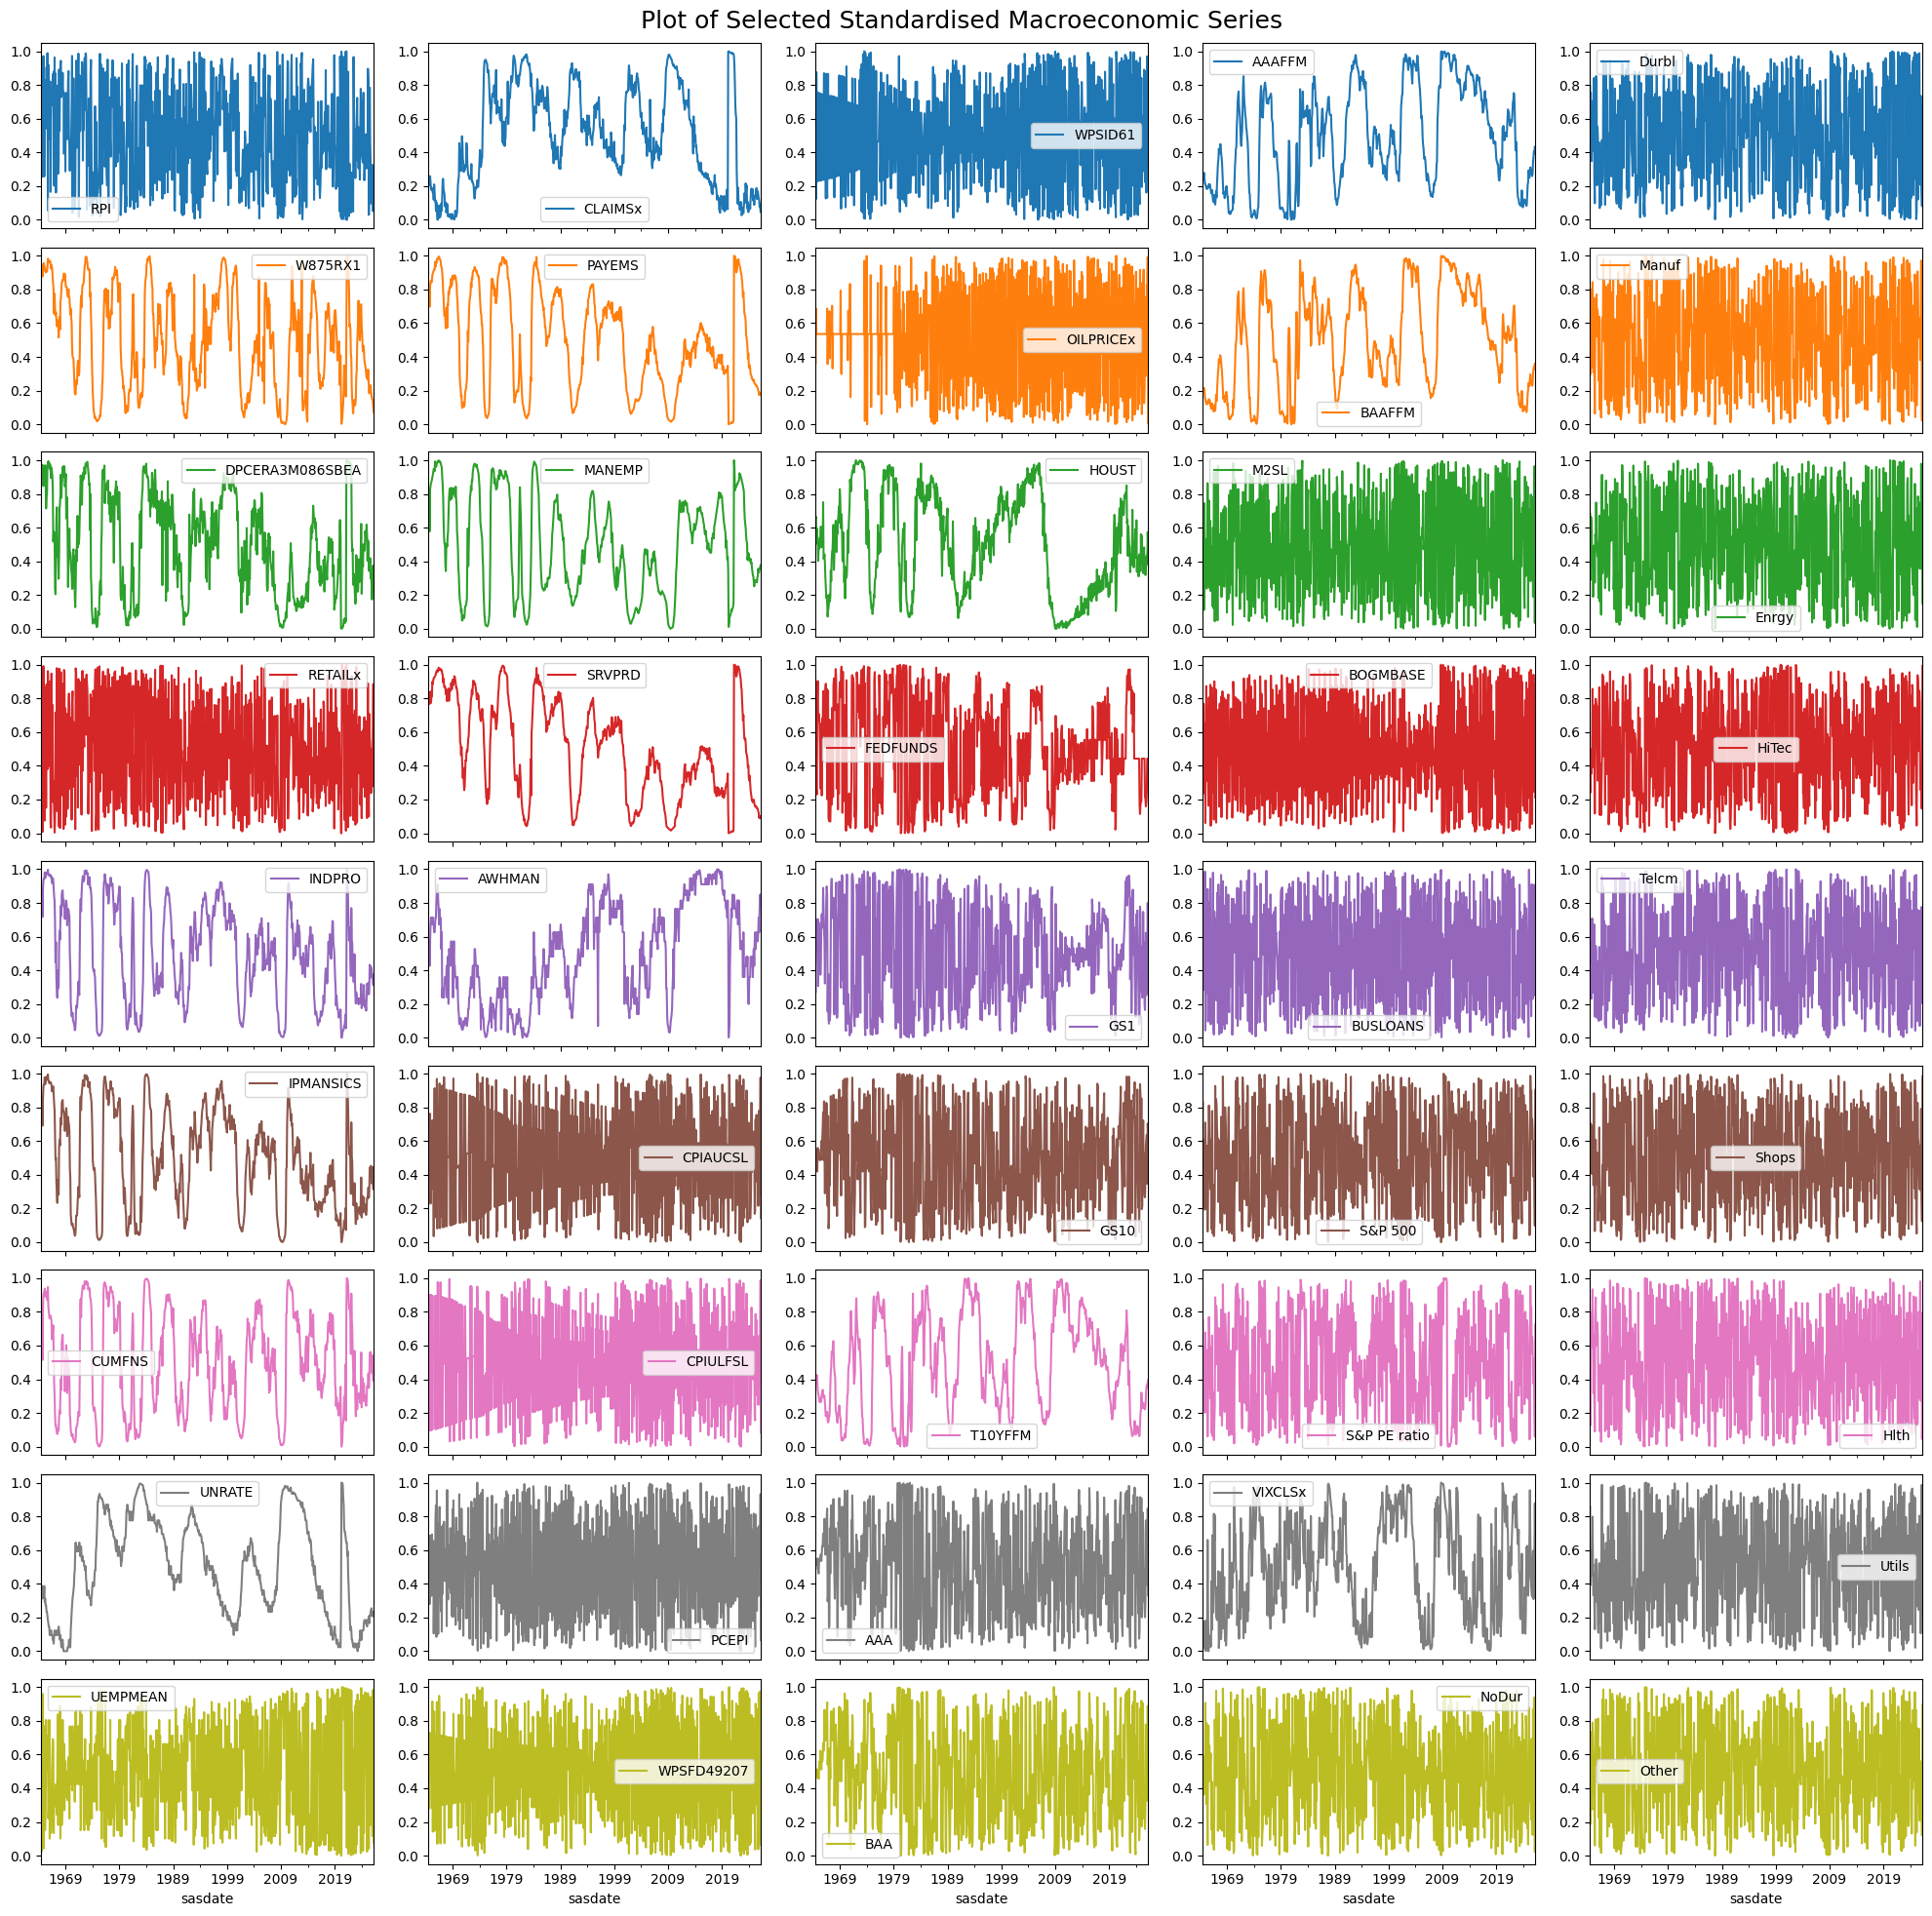

In [163]:
num_rows = 9; num_cols = 5
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 20), sharex=True)

fig.suptitle("Plot of Selected Standardised Macroeconomic Series", fontsize=18)

for col in range(num_cols):
    coli_axes = axes[:, col]
    joint_df_standardised[variables[num_rows*col:num_rows*(1+col)]].plot(subplots=True, ax=coli_axes)

plt.tight_layout(); plt.subplots_adjust(top=0.963); plt.show()

### Heatmap

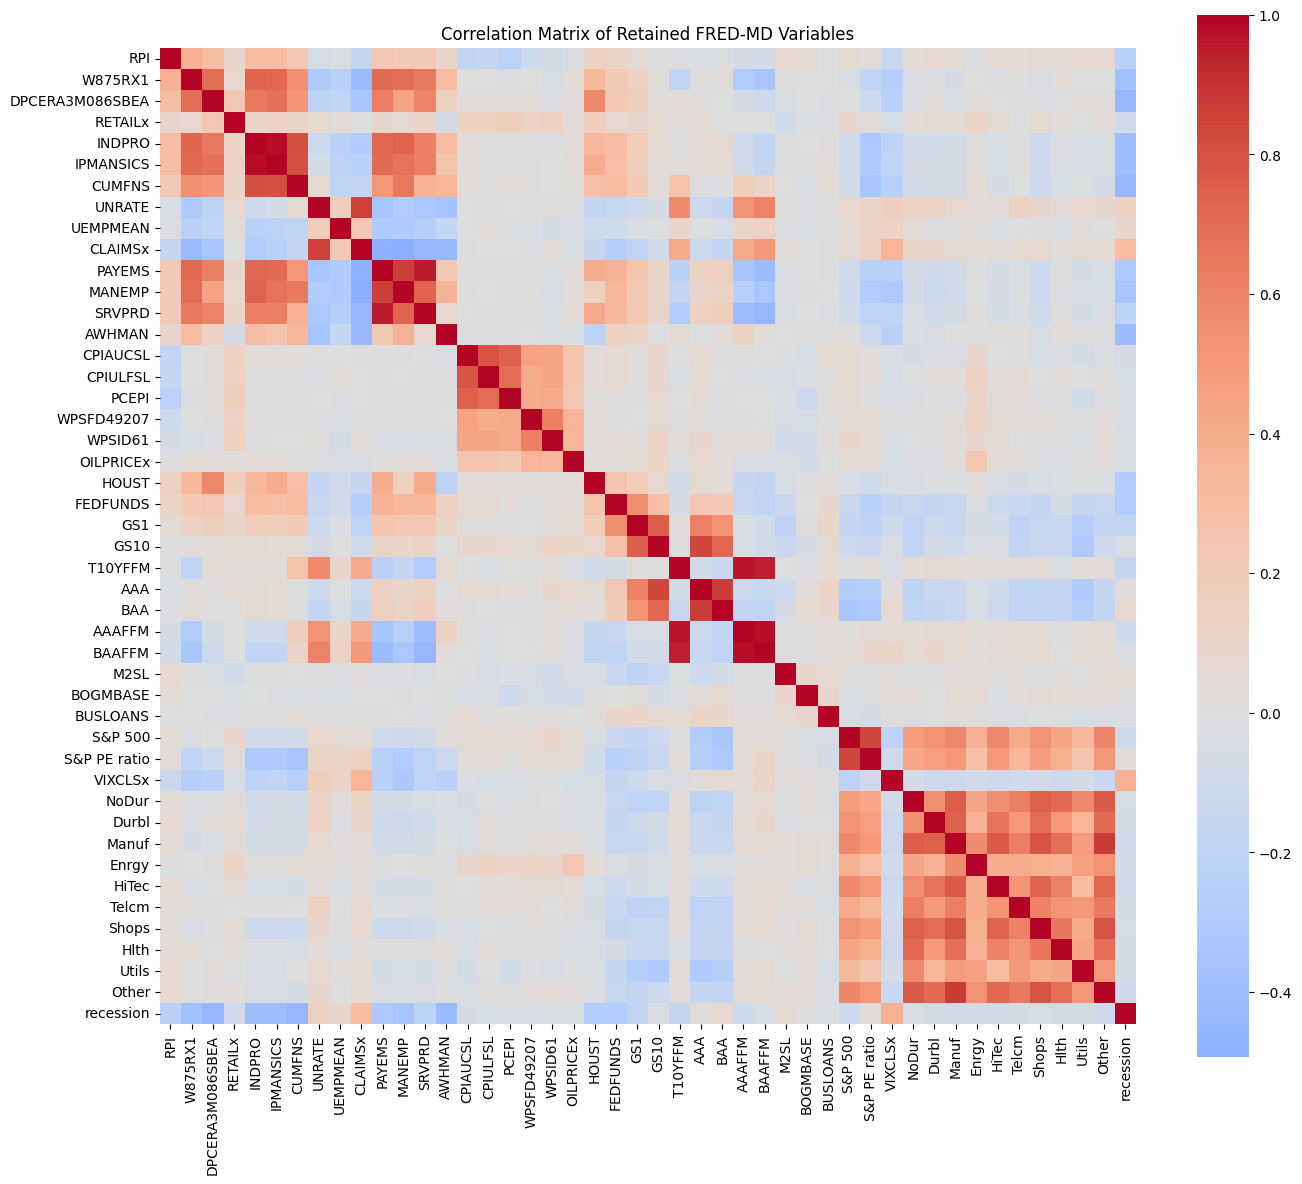

In [164]:
corr = final_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix of Retained FRED-MD Variables")
plt.tight_layout(); plt.show()

These correlations make sense, if needed we could remove one variable from some of the very highly correlated variables. Don't know if this is an issue yet.

### PCA Scree Plot

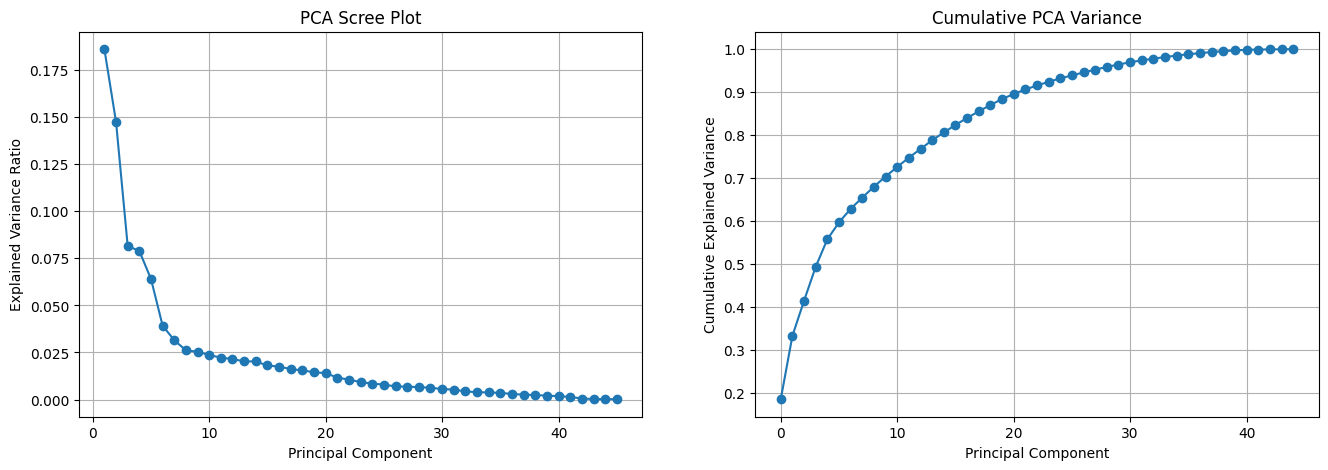

In [165]:
pca = PCA()
pca.fit(joint_df_standardised.to_numpy())

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figheight(5); fig.set_figwidth(16)

explained = pca.explained_variance_ratio_

ax1.plot(range(1, len(explained)+1), explained, marker="o")
ax1.set_xlabel("Principal Component"); ax1.set_ylabel("Explained Variance Ratio")
ax1.set_title("PCA Scree Plot"); ax1.grid(True)

ax2.plot(np.cumsum(explained), marker="o")
ax2.set_xlabel("Principal Component"); ax2.set_ylabel("Cumulative Explained Variance")
ax2.set_title("Cumulative PCA Variance"); ax2.grid(True)

plt.show()

# Fixing transformations
### Identify the offending series

On the first time around, my standardised data had some problems. The 'COVID spike' affected lots of my time series and caused the diffusion embedding to basically just be an indicator fundtion for when COVID occured. This was because during COVID lots of macroeconomic variables reached values which they had never reached before, this caused individual observations to be very far outside the mean of the data cloud. 

I needed to:
- Identify which series are causing the spikes
- Try different transformations to ensure stability for all series
    - Plot ACF
    - Compare kurtosis
- Once transformations are stationary, experimetn with different standardisations
    - Standard, Robust, MinMax, Yeo-Johnson/quantile


Below are a subset of the experiments I did to find and fix the preprocessing issues. I start by building my observation points with the standard transformations from FRED and the standard standardisation where $\bar z_t^j = \frac{z_t^j-\bar z^j}{s^j}$ for $j = 1, \ldots, D$. This is how I originally had my data.

In [66]:
### FRED-MD dataset
fred_md = pd.read_csv("./datasets/FRED_MD_2026_05.csv")

transforms = fred_md.loc[fred_md["sasdate"] == "Transform:"].iloc[0].drop("sasdate")
transforms = transforms.astype(int).to_dict()

fred_md = fred_md[fred_md["sasdate"] != "Transform:"].copy()
fred_md["sasdate"] = pd.to_datetime(fred_md["sasdate"], format="%m/%d/%Y")
fred_md = fred_md.set_index("sasdate"); fred_md = fred_md.apply(pd.to_numeric, errors="coerce")
fred_md = fred_md.sort_index(); fred_md = fred_md.loc["1963-6-01":"2026-04-01"]

fred_md_selected = fred_md[selected_cols]
fred_md_selected = fred_md_selected.interpolate(method="linear")

fred_md_transformed_original = pd.DataFrame(index=fred_md_selected.index)

for col in fred_md_selected.columns:   
    fred_md_transformed_original[col] = transform_series(fred_md_selected[col], transforms[col])

fred_md_transformed_original = fred_md_transformed_original.replace([np.inf, -np.inf], np.nan)
fred_md_transformed_original = fred_md_transformed_original.dropna()

### Prices
prices = pd.read_csv("./datasets/10_Industry_Portfolios.csv")
prices.set_index("Date", inplace=True)
prices.index = pd.to_datetime(prices.index.astype(str), format="%Y%m")
prices = prices.loc["1963-08-01":"2026-04-01"]

pre_standardsised_joint_original = fred_md_transformed_original.join(prices, on="sasdate")

# This is the dataset I had originally
testing_df = (pre_standardsised_joint_original - pre_standardsised_joint_original.mean()) / pre_standardsised_joint_original.std()

### Identifying which dates cause most of the problems
The problem being a data point very var away from the mean

In [67]:
def df_row_norms(testing_df):
    row_norm_sq = (testing_df ** 2).sum(axis=1)
    row_norm = np.sqrt(row_norm_sq)

    row_norms = pd.DataFrame({
            "row_index": np.arange(len(testing_df)),
            "date": testing_df.index,
            "row_norm": row_norm.values,
            "row_norm_sq": row_norm_sq.values,
        }).sort_values("row_norm", ascending=False)

    row_norms.set_index("row_index", inplace=True)
    display(row_norms.head(10))
    print(f'Row norm squared mean: {row_norms["row_norm_sq"].mean()}')
    print(f'Row norm squared standard deviation: {row_norms["row_norm_sq"].std()}')

df_row_norms(testing_df)

,date,row_norm,row_norm_sq
row_index,,,
680,2020-04-01,61.088205,3731.768742
679,2020-03-01,33.857954,1146.361081
681,2020-05-01,27.616714,762.682903
682,2020-06-01,23.792593,566.087479
542,2008-10-01,21.335225,455.191840
201,1980-05-01,20.017680,400.707507
691,2021-03-01,18.764300,352.098941
545,2009-01-01,16.064634,258.072480
290,1987-10-01,15.297257,234.006061


Row norm squared mean: 44.940239043824704
Row norm squared standard deviation: 149.76223030807554


Clearly COVID is a massive shock, with the top 4 highest row norms. I am choosing to investigate 4 different dates to see which series are the probelm. The 1978 squared norm is just over 1 standard deviation away from the mean, so this spike may not actually be a problem, and hopefully nothing less than this is a problem either.

In [68]:
problem_idxs = {"COVID": 680, "2008 Financial Crisis": 542, "1980s recession": 201, "1987 Black Monday": 290}

### Identifying which variables are causing the problem

Worst variables by max z-score and Kurtosis


,kurtosis,max_abs_z,idx_max_abs_z,mean_abs_z
SRVPRD,551.062025,25.338008,2020-04-01,0.264520
PAYEMS,502.829428,24.766856,2020-04-01,0.300243
UNRATE,431.985089,23.844617,2020-04-01,0.339017
CLAIMSx,310.794469,21.892788,2020-03-01,0.396945
MANEMP,147.066340,18.181212,2020-04-01,0.511557
IPMANSICS,78.454157,15.395460,2020-04-01,0.581602
RPI,115.466354,15.119396,2021-03-01,0.343363
INDPRO,72.238857,15.069151,2020-04-01,0.593157
DPCERA3M086SBEA,86.778400,14.879404,2020-04-01,0.508625
CUMFNS,55.785362,14.084051,2020-04-01,0.604913


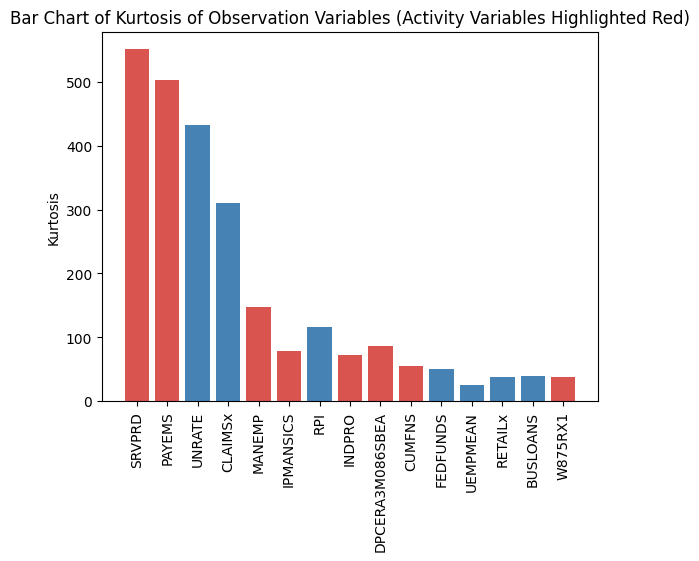

In [69]:
def df_col_stats(testing_df):
    summary = pd.DataFrame(index=testing_df.columns)
    summary["kurtosis"] = testing_df.kurtosis(axis=0)  # pandas gives excess kurtosis
    summary["max_abs_z"] = testing_df.abs().max(axis=0)
    summary["idx_max_abs_z"] = testing_df.abs().idxmax(axis=0)
    summary["mean_abs_z"] = testing_df.abs().mean(axis=0)
    summary.sort_values(["max_abs_z", "kurtosis"], ascending=False, inplace=True)
    print("Worst variables by max z-score and Kurtosis")
    summary = summary.head(15)
    display(summary)

    activity_vars = ["SRVPRD", "PAYEMS", "MANEMP", "IPMANSICS", "INDPRO", "DPCERA3M086SBEA", "CUMFNS", "W875RX1"]
    bar_colors = ["#d9534f" if idx in activity_vars else "#4682b4" for idx in summary.index]

    plt.bar(summary.index, summary["kurtosis"], color=bar_colors)
    plt.xticks(rotation=90); plt.ylabel("Kurtosis")
    plt.title("Bar Chart of Kurtosis of Observation Variables (Activity Variables Highlighted Red)")
    plt.show()

df_col_stats(testing_df)

The kurtosis is very high for lots of these variables. Activity variables are able to be transformed using YoY transformations instead of MoM, this can lower kurtosis. `UNRATE` and `CLAIMSx` are not activity variables and we will have to look closer at them and YoY may not make sense/fix these two.

A high row norm $\|z_t\| = \sqrt(\sum_{j=1}^Dz_{t,j}^2)$ means that the data point is far away from the centre of the data cloud.

### Do the same variables always cause the problems?

For each of the offending dates (in `problem_idxs`) I will check the contribution to the norm of each variable. This will show me which variables are causing problems at different times, rather than just for the COVID spike.

In [70]:

def variable_shock_diagnostics(Z_std, variables=None, dates=None, row_idx=680, top_n=15, display_df=True):
    # Convert to DataFrame
    if isinstance(Z_std, pd.DataFrame):
        Zdf = Z_std.copy()
    else:
        if variables is None:
            variables = [f"x{j}" for j in range(Z_std.shape[1])]
        if dates is None:
            dates = np.arange(Z_std.shape[0])
        Zdf = pd.DataFrame(Z_std, columns=variables, index=dates)

    row_j = Zdf.iloc[row_idx]
    row_j_contrib = pd.DataFrame({
        "variable": Zdf.columns,
        "row_j_abs_z": row_j.abs().values,
        "contribution_to_row_j_norm_sq": (row_j.values ** 2),
        "share_of_row_j_norm_sq": (row_j.values ** 2) /np.sum(row_j.values ** 2)
    })
    row_j_contrib = row_j_contrib.sort_values("contribution_to_row_j_norm_sq", ascending=False)

    if display_df:
        print(f"\nTop {top_n} variable contributions at idx={row_idx}:"); display(row_j_contrib.head(top_n))

    return row_j_contrib

In [71]:
html_elements = []

for name, idx in problem_idxs.items():
    row_j_contrib = variable_shock_diagnostics(
        testing_df, row_idx=idx, top_n=10, display_df=False
    )
    df_head = row_j_contrib.head(10).round(2)

    card_html = f"""
    <div style="flex: 1; min-width: 45%; max-width: 48%; margin: 10px; box-sizing: border-box;">
        <h4 style="margin-bottom: 5px; text-align: left;">{name}</h4>
        {df_head.to_html()}
    </div>
    """
    html_elements.append(card_html)

grid_html = f"""
<div style="text-align: center; font-weight: bold; font-size: 18px; margin-bottom: 12px;">
    The most influential variable for 4 different shock dates
</div>
<div style="display: flex; flex-wrap: wrap; justify-content: space-between; width: 100%;">
    {"".join(html_elements)}
</div>
"""
display(HTML(grid_html))


,variable,row_j_abs_z,contribution_to_row_j_norm_sq,share_of_row_j_norm_sq
12,SRVPRD,25.34,642.01,0.17
10,PAYEMS,24.77,613.40,0.16
7,UNRATE,23.84,568.57,0.15
11,MANEMP,18.18,330.56,0.09
5,IPMANSICS,15.40,237.02,0.06
4,INDPRO,15.07,227.08,0.06
2,DPCERA3M086SBEA,14.88,221.40,0.06
6,CUMFNS,14.08,198.36,0.05
8,UEMPMEAN,11.49,131.93,0.04
1,W875RX1,10.54,111.09,0.03


As you said, the "activity" variables dominate the COVID spike, but it's more fiscal policy/stock market variables causing the spike in 2008 and 1980. Because the COVID spike is so much bigger than the rest, I focused on fixing it, rather than addressing the other variables.

After making the appropriate YoY transformations to selected activity variables, I redid the above analysis and found that `UNRATE` and `CLAIMSx` were still causing massive spikes which led to the diffusion coordinates not being able to provide us with a meaningfull embedding.

### Trying to fix `UNRATE` and `CLAIMSx`

I aim to make these series more stationary, with lower kurtosis scores and less dominant in the COVID row norm via an economically justifiable transformation. Below I transform `UNRATE` and `CLAIMSx` in many different ways and I check the kurtosis and stationarity of the resulting transformation.

In [72]:
from statsmodels.tsa.stattools import adfuller, acf, kpss
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter('ignore', InterpolationWarning)

def transform_candidate(x, name):
    x = x.astype(float)
    if name == "level": return x
    if name == "diff": return x.diff()
    if name == "diff_12": return x.diff(12)
    if name == "log_level":  return np.log(x)
    if name == "log_diff": return np.log(x).diff()
    if name == "log_diff_12": return np.log(x).diff(12)
    if name == "pct_change": return x.pct_change()
    if name == "pct_change_12": return x.pct_change(12)
    raise ValueError(f"Unknown transform: {name}")

def safe_adf_pvalue(x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()
    if len(x) < 20 or x.std() == 0:
        return np.nan
    try:
        return adfuller(x, autolag="AIC")[1]
    except Exception:
        return np.nan

def lag1_acf(x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()
    if len(x) < 20 or x.std() == 0:
        return np.nan
    return acf(x, nlags=1, fft=True)[1]

def compare_transforms(df, vars_to_test, transform_options):
    rows = []; transformed = {}
    for var in vars_to_test:
        transformed[var] = {}
        for tr in transform_options[var]:
            s = transform_candidate(df[var], tr).replace([np.inf, -np.inf], np.nan).dropna(); transformed[var][tr] = s
            rows.append({"variable": var, "transform": tr, "n_obs": len(s), "mean": s.mean(), "std": s.std(), "kurtosis": s.kurtosis(), 
                         "max_abs": s.abs().max(), "mean_abs": s.abs().mean(), "lag1_acf": lag1_acf(s), "adf_pvalue": safe_adf_pvalue(s), "kpss_pvalue": kpss(s)[0]})
    stats = pd.DataFrame(rows)
    return stats, transformed

In [73]:
vars_to_test = ["UNRATE", "CLAIMSx"]

transform_options = {"UNRATE": ["level", "diff", "diff_12"],
                     "CLAIMSx": ["level", "log_level", "log_diff", "log_diff_12", "pct_change", "pct_change_12"]}

stats, transformed = compare_transforms(fred_md_selected, vars_to_test, transform_options)

display(stats.sort_values(["variable", "kurtosis", "max_abs"]))

,variable,transform,n_obs,mean,std,kurtosis,max_abs,mean_abs,lag1_acf,adf_pvalue,kpss_pvalue
4,CLAIMSx,log_level,755,12.706974,0.327392,8.826720,1.535522e+01,12.706974,0.942257,4.030856e-04,0.340461
6,CLAIMSx,log_diff_12,743,-0.003753,0.344802,21.377296,3.101552e+00,0.182605,0.892502,8.075479e-10,0.039421
3,CLAIMSx,level,755,353708.556291,219752.810470,211.757355,4.663250e+06,353708.556291,0.764650,1.836379e-08,0.198896
8,CLAIMSx,pct_change_12,743,0.091644,1.025861,264.329625,2.123242e+01,0.244513,0.737364,2.487476e-11,0.151340
5,CLAIMSx,log_diff,754,-0.000430,0.109931,311.186418,2.407815e+00,0.043665,0.176984,2.165904e-22,0.028244
7,CLAIMSx,pct_change,754,0.011953,0.374336,705.835574,1.010966e+01,0.053760,0.090721,0.000000e+00,0.133174
0,UNRATE,level,755,5.852252,1.734775,0.949702,1.480000e+01,5.852252,0.967922,1.589061e-02,0.268651
2,UNRATE,diff_12,743,-0.018237,1.374717,14.028619,1.110000e+01,0.865747,0.897981,2.401114e-06,0.043262
1,UNRATE,diff,754,-0.001724,0.435940,432.558550,1.040000e+01,0.147347,0.029980,6.716740e-28,0.033041


I am deciding to change the `UNRATE` transform to levels because it still makes economic sense and gives a nice series. Log level for `CLAIMSx` is the only reasonable choice in terms of kurtosis, ADF, and KPSS, but if we use this, then we get the current level of people needing benefits, rather than whether the job market is deteriorating or improving and at what rate. This maybe makes this variable a bit redundant.


### Visualising the new transformations

In [74]:
new_transform_vars = ["SRVPRD", "PAYEMS", "MANEMP", "IPMANSICS", "INDPRO", "DPCERA3M086SBEA", "CUMFNS", "W875RX1", "UNRATE", "CLAIMSx"]

new_transforms = pd.DataFrame(index=fred_md_selected.index)

for col in new_transform_vars[:-2]:    
    new_transforms[col] = transform_series(fred_md_selected[col], transforms[col], lag=12)

new_transforms = new_transforms.replace([np.inf, -np.inf], np.nan)
new_transforms = new_transforms.dropna()


# 1-level, 2-diff, 3-second diff, 4-log level, 5-log diff, 6-log second diff, 7-pct change diff
new_transforms["UNRATE"] = transform_series(fred_md_selected["UNRATE"], 1)
new_transforms["CLAIMSx"] = transform_series(fred_md_selected["CLAIMSx"], 4)


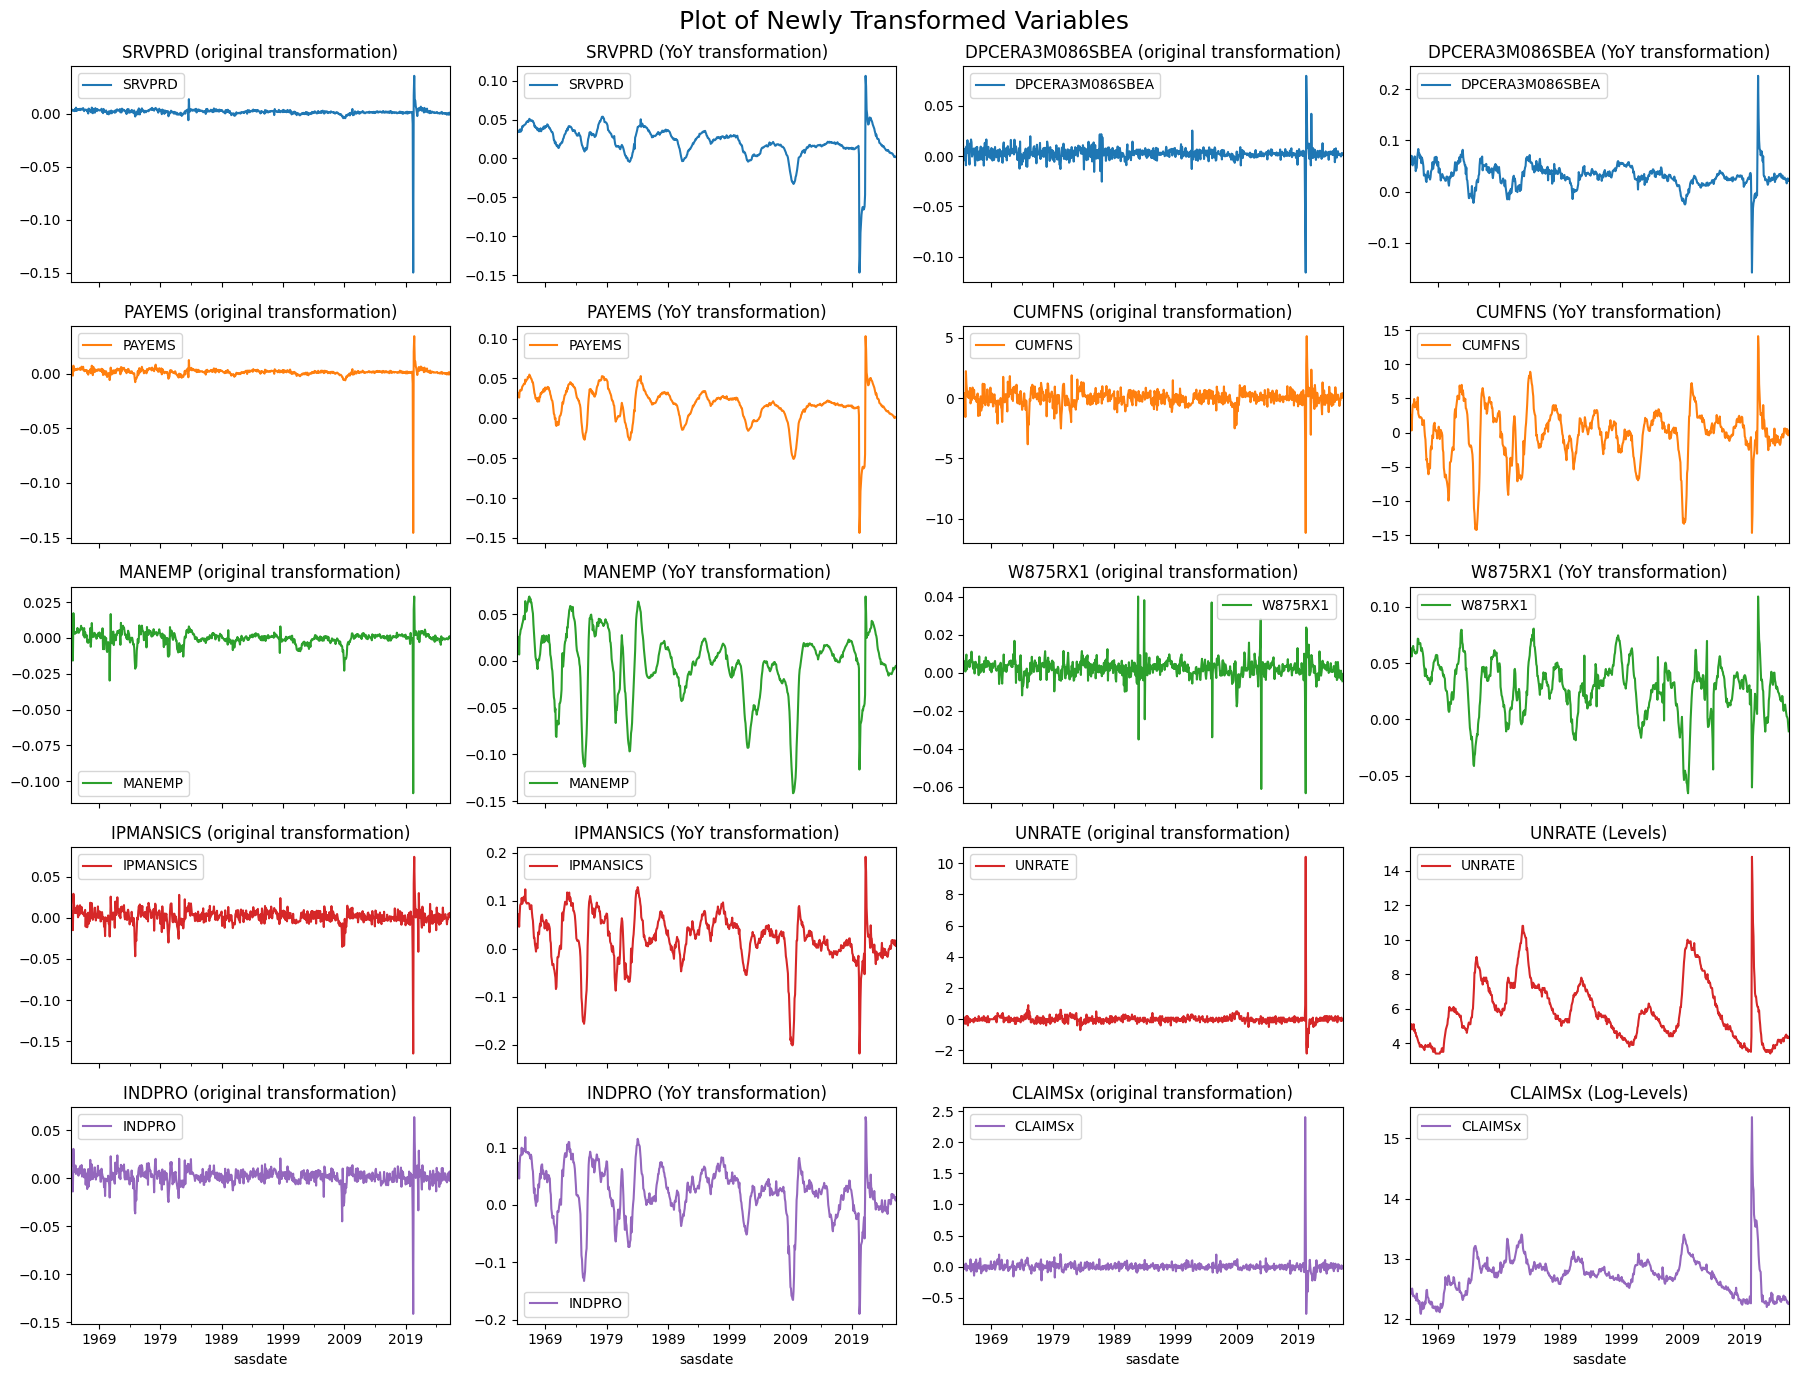

In [75]:
num_rows = 5; num_cols = 4
fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 14), sharex=True)

fig.suptitle("Plot of Newly Transformed Variables", fontsize=18)

for col in range(num_cols//2):
    coli_axes = axes[:, col*2]; colj_axes = axes[:, 1+(col*2)]
    current_vars = new_transform_vars[num_rows*col:num_rows*(1+col)]
    fred_md_transformed_original[current_vars].plot(subplots=True, ax=coli_axes)
    new_transforms[current_vars].plot(subplots=True, ax=colj_axes)

    for i, var in enumerate(current_vars):
        coli_axes[i].set_title(f"{var} (original transformation)")
        if var == "UNRATE":
            colj_axes[i].set_title("UNRATE (Levels)")
        elif var == "CLAIMSx":
            colj_axes[i].set_title("CLAIMSx (Log-Levels)")
        else:
            colj_axes[i].set_title(f"{var} (YoY transformation)")

plt.tight_layout(); plt.subplots_adjust(top=0.94); plt.show()

# Fixing standardisation
This was done after I found the appropriate transformations.

Below I employ several common standardisation methods and report key statistics of the resulting data. I will choose which method I proceed with based on these results.

In [76]:
from mlxtend.preprocessing import minmax_scaling
from sklearn.preprocessing import RobustScaler, PowerTransformer, quantile_transform

pre_standardsised_joint = fred_md_transformed.join(prices, on="sasdate")

standard = (pre_standardsised_joint - pre_standardsised_joint.mean()) / pre_standardsised_joint.std()
robust = pd.DataFrame(RobustScaler().fit_transform(pre_standardsised_joint), index=pre_standardsised_joint.index, columns=pre_standardsised_joint.columns)
minmax = minmax_scaling(pre_standardsised_joint, columns=pre_standardsised_joint.columns)
yeo_johnson = pd.DataFrame(PowerTransformer(method="yeo-johnson").fit_transform(pre_standardsised_joint), index=pre_standardsised_joint.index, columns=pre_standardsised_joint.columns)
quantile = pd.DataFrame(quantile_transform(pre_standardsised_joint, n_quantiles=pre_standardsised_joint.shape[0]), index=pre_standardsised_joint.index, columns=pre_standardsised_joint.columns)

In [77]:
datasets = {"Standard": standard, "Robust": robust, "MinMax": minmax, "Yeo-Johnson": yeo_johnson, "Quantile": quantile}

rows = []

for name, X in datasets.items():
    row_norm = np.linalg.norm(X.values, axis=1); max_idx = np.argmax(row_norm); covid_idx = X.index.get_loc("2020-04-01")
    covid_row_norm = row_norm[covid_idx]; covid_relitive_norm = covid_row_norm / np.median(row_norm)
    rows.append({"method": name, "max_abs_z": np.abs(X.values).max(), "99% abs": np.quantile(np.abs(X.values), 0.99), "max row norm": row_norm[max_idx],
                 "99% row norm": np.quantile(row_norm, 0.99), "row norm ratio": row_norm[max_idx] / np.quantile(row_norm, 0.99), "mean row norm": row_norm.mean(),
                 "std row norm": row_norm.std(), "date": X.index[max_idx], "max kurtosis": X.kurtosis().max(), "mean kurtosis": X.kurtosis().mean(),
                 "covid row norm": covid_row_norm, "covid relative norm": covid_relitive_norm})

diagnostics = pd.DataFrame(rows)

display(diagnostics)

,method,max_abs_z,99% abs,max row norm,99% row norm,row norm ratio,mean row norm,std row norm,date,max kurtosis,mean kurtosis,covid row norm,covid relative norm
0,Standard,15.027783,3.279396,29.847317,17.309814,1.724300,6.080416,2.822761,2020-04-01,114.141448,10.863734,29.847317,5.598986
1,Robust,44.262485,3.559213,45.780912,22.516183,2.033245,6.454626,4.098675,2021-03-01,114.141448,10.863734,41.177517,7.634471
2,MinMax,1.000000,0.906846,4.422433,4.136733,1.069064,3.718435,0.196610,2021-04-01,114.141448,10.863734,4.010447,1.075998
3,Yeo-Johnson,14.600473,3.022130,25.367676,15.999024,1.585576,6.194001,2.575724,2020-04-01,109.549899,8.816579,25.367676,4.581983
4,Quantile,1.000000,0.990566,5.148437,4.822142,1.067666,3.842112,0.494862,1978-04-01,-1.167607,-1.199051,4.387208,1.130791


- Robust standardisation doesn't seem to work since the maximum value is almost 3x the maximum value of the standard method. 
- Lots of the minmax numbers look good, but that's because everything has been squished between into $[0,1]$, The fact that the kurtosis value hasn't changed from the standard method suggests that this is simply downscaling, rather than fixing the problem.
- The Yeo-Johnson scaling seems to have improved every metric slightly (apart from mean row norm) which makes me think this can't have been harmful to the data
- Quantile looks too good to be true. I imagine that all the stucture has been ruined via this standardisation. I will test in Phase 2